In [12]:
%%bash
wget -q https://cdn.oxfordnanoportal.com/software/analysis/dorado-1.4.0-linux-x64.tar.gz
tar -xzf dorado-1.4.0-linux-x64.tar.gz

# Add the lib directory to the library path
export LD_LIBRARY_PATH=/content/dorado-1.4.0-linux-x64/lib:$LD_LIBRARY_PATH
echo "export LD_LIBRARY_PATH=/content/dorado-1.4.0-linux-x64/lib:\$LD_LIBRARY_PATH" >> ~/.bashrc

# Create a wrapper script that sets the library path
echo '#!/bin/bash
export LD_LIBRARY_PATH=/content/dorado-1.4.0-linux-x64/lib:$LD_LIBRARY_PATH
/content/dorado-1.4.0-linux-x64/bin/dorado "$@"' > /usr/local/bin/dorado
chmod +x /usr/local/bin/dorado

# Test
dorado --version

apt-get install -qq samtools minimap2 > /dev/null 2>&1
pip install -q pod5 biopython matplotlib numpy pysam > /dev/null 2>&1
echo "✓ Dorado 1.4.0 installed"

1.4.0+ba44a013
✓ Dorado 1.4.0 installed


[2026-03-08 19:09:39.443] [info] Running: "--version"


In [18]:
import os
os.makedirs("dorado_data", exist_ok=True)
os.makedirs("dorado_results", exist_ok=True)

print("=" * 60)
print("DOWNLOADING REAL NANOPORE SEQUENCING DATA")
print("  Source: ONT official basecalling demo dataset")
print("=" * 60)

!wget -q --show-progress \
    "https://ont-exd-int-s3-euwst1-epi2me-labs.s3.amazonaws.com/wf-basecalling/wf-basecalling-demo.tar.gz" \
    -O dorado_data/demo.tar.gz

!cd dorado_data && tar -xzf demo.tar.gz

POD5_FILE = "dorado_data/wf-basecalling-demo/input/PAW70337_66b2eea5_de8117b1_1.1k.pod5"

print(f"\nUsing: {POD5_FILE}")
print(f"File size: {os.path.getsize(POD5_FILE) / 1e6:.1f} MB")

import subprocess
result = subprocess.run(["pod5", "view", POD5_FILE, "--no-header"],
                        capture_output=True, text=True)
num_reads = len(result.stdout.strip().split("\n"))
print(f"Total reads: {num_reads}")

DOWNLOADING REAL NANOPORE SEQUENCING DATA
  Source: ONT official basecalling demo dataset
dorado_data/demo.ta 100%[===================>]   1.77G  18.8MB/s    in 1m 40s  

Using: dorado_data/wf-basecalling-demo/input/PAW70337_66b2eea5_de8117b1_1.1k.pod5
File size: 188.6 MB
Total reads: 1000


In [19]:
###basecalling(sup model)
import time

print("=" * 60)
print("FEATURE 1: STANDARD BASECALLING")
print("  Raw electrical signals → DNA sequences")
print("  Model: sup (super-accuracy, transformer-based)")
print("=" * 60)

POD5_FILE = "dorado_data/wf-basecalling-demo/input/PAW70337_66b2eea5_de8117b1_1.1k.pod5"

start = time.time()
!dorado basecaller sup {POD5_FILE} \
    --emit-fastq > dorado_results/basecalled.fastq 2> dorado_results/basecall.log

elapsed_bc = time.time() - start

num_basecalled = !grep -c "^@" dorado_results/basecalled.fastq
print(f"\n✓ Basecalling complete in {elapsed_bc:.1f}s")
print(f"  Reads basecalled: {num_basecalled[0]}")

print("\nSample output (first read):")
!head -4 dorado_results/basecalled.fastq

# If 0 reads, show log for debugging
if num_basecalled[0].strip() == "0":
    print("\n⚠️ Check basecall log:")
    !tail -20 dorado_results/basecall.log

FEATURE 1: STANDARD BASECALLING
  Raw electrical signals → DNA sequences
  Model: sup (super-accuracy, transformer-based)

✓ Basecalling complete in 352.3s
  Reads basecalled: 1027

Sample output (first read):
@dfd4f6bb-ebb8-429d-933a-f93d25ee56d9	qs:f:20.5685	ch:i:766	st:Z:2024-06-19T13:02:49.656000+00:00	RG:Z:66b2eea5-f887-4690-bd76-97fd9c4e416b_dna_r10.4.1_e8.2_400bps_sup@v5.2.0	DS:Z:gpu:Tesla T4	PU:Z:PAW70337	DT:Z:2024-06-19T12:36:05.543000+00:00
...
+
,(&'%&$%$%%@B=>IHKSJFFA@?@??@LFF<:;0.---123GFEFEDEIHA@@@@DKJHEESPKISJGGISOSRIBGDFIEDA@AEA@HECBBDEQNKSSSSLSKSSL9;DDQGSSSSSLSMHOJNSSSSSMSSNKLISSSHC@DJNN@@JMLOSSONF<LSSSSSSSSSSOBBAGFDJ<SDHHGDEISPKNJSONKGJS;<<;;HKJNSMJSSO****)025;6550('',000010-,+'&%%'(,0000SSNSLIH>888FFD@????@@?BCFEFFDEFFEELSMSNKSSQSSNHIJGFFAAAAARGECB@@B>=44>BDF:8888779:;B::FEGLMJKKJHSMJII/////17DHIILBBBCFIC@GGABJBB@@?@@A@E@@@@@MMSSS99:99DBBCIESSGGHHLBA4023NKJPSSSSSOSSSNSPMNSSSSSSSSSSSOPMPSSSSSOSSSSNNKDDDDFSGHQNGM<2))655CH44SFGG>=;IS:999GGISSSSSSSOSNIIIK<:86+'''''%(,,+-

In [20]:
###modified base detection
print("=" * 60)
print("FEATURE 2: MODIFIED BASE DETECTION")
print("  Detects 5mC and 5hmC methylation in CpG context")
print("  Epigenetic modifications — same pass as basecalling")
print("=" * 60)

POD5_FILE = "dorado_data/wf-basecalling-demo/input/PAW70337_66b2eea5_de8117b1_1.1k.pod5"

start = time.time()
!dorado basecaller sup,5mCG_5hmCG {POD5_FILE} \
    > dorado_results/modbase.bam 2> dorado_results/modbase.log

elapsed_mod = time.time() - start
print(f"\n✓ Modified base calling complete in {elapsed_mod:.1f}s")

!samtools flagstat dorado_results/modbase.bam 2>/dev/null | head -3

print("\nChecking for methylation tags in BAM:")
mod_tags = !samtools view dorado_results/modbase.bam 2>/dev/null | head -1 | tr '\t' '\n' | grep -E "^(MM|ML)"
if mod_tags:
    for tag in mod_tags[:3]:
        print(f"  {tag[:80]}...")
    print("\n  MM tag = modification type + positions in read")
    print("  ML tag = probability of modification at each position (0-255)")
else:
    print("  No modification tags detected in this dataset")
    print("  On native genomic DNA, MM/ML tags contain methylation calls")

FEATURE 2: MODIFIED BASE DETECTION
  Detects 5mC and 5hmC methylation in CpG context
  Epigenetic modifications — same pass as basecalling

✓ Modified base calling complete in 391.8s
1003 + 0 in total (QC-passed reads + QC-failed reads)
1003 + 0 primary
0 + 0 secondary

Checking for methylation tags in BAM:
  MM:Z:C+h?,77,2,28,6,8,59,26;C+m?,77,2,28,6,8,59,26;...
  ML:B:C,1,1,3,1,7,1,4,3,255,253,254,4,255,3...

  MM tag = modification type + positions in read
  ML tag = probability of modification at each position (0-255)


In [22]:
###basecalling + alignment
print("=" * 60)
print("FEATURE 3: BASECALLING + ALIGNMENT")
print("  Dorado has built-in minimap2 — single command")
print("=" * 60)

POD5_FILE = "dorado_data/wf-basecalling-demo/input/PAW70337_66b2eea5_de8117b1_1.1k.pod5"

# Use the basecalled reads to create our own reference from the longest read
# This guarantees alignment will work for the demo
!head -4 dorado_results/basecalled.fastq > dorado_data/mini_ref.fasta
# Convert FASTQ to FASTA format for reference
!awk 'NR==1{print ">"substr($0,2)} NR==2{print}' dorado_results/basecalled.fastq > dorado_data/mini_ref.fasta

# Better approach: download E. coli reference (small, commonly used with ONT)
!wget -q "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz" \
    -O dorado_data/ecoli_ref.fna.gz
!gunzip -f dorado_data/ecoli_ref.fna.gz

REF_FILE = "dorado_data/ecoli_ref.fna"
print(f"Reference: E. coli K-12 genome (4.6 Mb)")

import time
start = time.time()
!dorado basecaller sup {POD5_FILE} \
    --reference {REF_FILE} \
    > dorado_results/aligned.bam 2> dorado_results/aligned.log

elapsed_align = time.time() - start

!samtools sort dorado_results/aligned.bam -o dorado_results/aligned_sorted.bam 2>/dev/null
!samtools index dorado_results/aligned_sorted.bam 2>/dev/null

print(f"\n✓ Basecall + alignment complete in {elapsed_align:.1f}s")
print("\nAlignment statistics:")
!samtools flagstat dorado_results/aligned_sorted.bam

print("\nNote: Low mapping rate is expected — demo reads may not be E. coli.")
print("This demonstrates the alignment workflow: basecall + align in one step.")

FEATURE 3: BASECALLING + ALIGNMENT
  Dorado has built-in minimap2 — single command
Reference: E. coli K-12 genome (4.6 Mb)

✓ Basecall + alignment complete in 370.9s

Alignment statistics:
1003 + 0 in total (QC-passed reads + QC-failed reads)
1003 + 0 primary
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
0 + 0 mapped (0.00% : N/A)
0 + 0 primary mapped (0.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)

Note: Low mapping rate is expected — demo reads may not be E. coli.
This demonstrates the alignment workflow: basecall + align in one step.


In [23]:
##QC meterics

print("=" * 60)
print("FEATURE 4: DORADO SUMMARY")
print("  Per-read quality metrics and statistics")
print("=" * 60)

!dorado summary dorado_results/modbase.bam \
    > dorado_results/read_summary.tsv 2>/dev/null

print("Per-read summary table (first 5 rows):")
!head -5 dorado_results/read_summary.tsv

try:
    import pandas as pd
    df = pd.read_csv("dorado_results/read_summary.tsv", sep="\t")
    print(f"\n{len(df)} reads in summary")
    print(f"\nColumns: {list(df.columns)}")
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    if numeric_cols:
        print(f"\nKey statistics:")
        print(df[numeric_cols[:6]].describe().round(2).to_string())
except Exception as e:
    print(f"  (Could not parse summary: {e})")


FEATURE 4: DORADO SUMMARY
  Per-read quality metrics and statistics
Per-read summary table (first 5 rows):
input_filename	batch_id	parent_read_id	read_id	run_id	channel	mux	minknow_events	start_time	duration	passes_filtering	template_start	num_events_template	template_duration	sequence_length_template	mean_qscore_template	pore_type	experiment_id	sample_id	end_reason
PAW70337_66b2eea5_de8117b1_1.1k.pod5	0	b1b01b8f-7006-4f0d-8e9d-12eaf6107d13	b1b01b8f-7006-4f0d-8e9d-12eaf6107d13	66b2eea5-f887-4690-bd76-97fd9c4e416b	275	2	1486	1312.489990	2.327600	TRUE	1312.580811	1864	2.236800	900	23.470793	not_set	20240619_human-var_protocol_cell_line_AS	ONLL08362	signal_positive
PAW70337_66b2eea5_de8117b1_1.1k.pod5	0	6a76a54d-c802-4b0a-beb6-a8fcf59307bc	6a76a54d-c802-4b0a-beb6-a8fcf59307bc	66b2eea5-f887-4690-bd76-97fd9c4e416b	1552	4	27136	1243.661011	45.957199	TRUE	1243.773438	38204	45.844799	17115	26.888100	not_set	20240619_human-var_protocol_cell_line_AS	ONLL08362	signal_positive
PAW70337_66b2eea5_de

BASECALLING QUALITY SUMMARY
  Total reads:       1003
  Total bases:       16,854,598
  Mean read length:  16804 bp
  Median length:     14055 bp
  Longest read:      92,487 bp
  Mean quality:      Q39.5
  Mean GC content:   40.4%
  Reads >= Q20:      888 (88.5%)


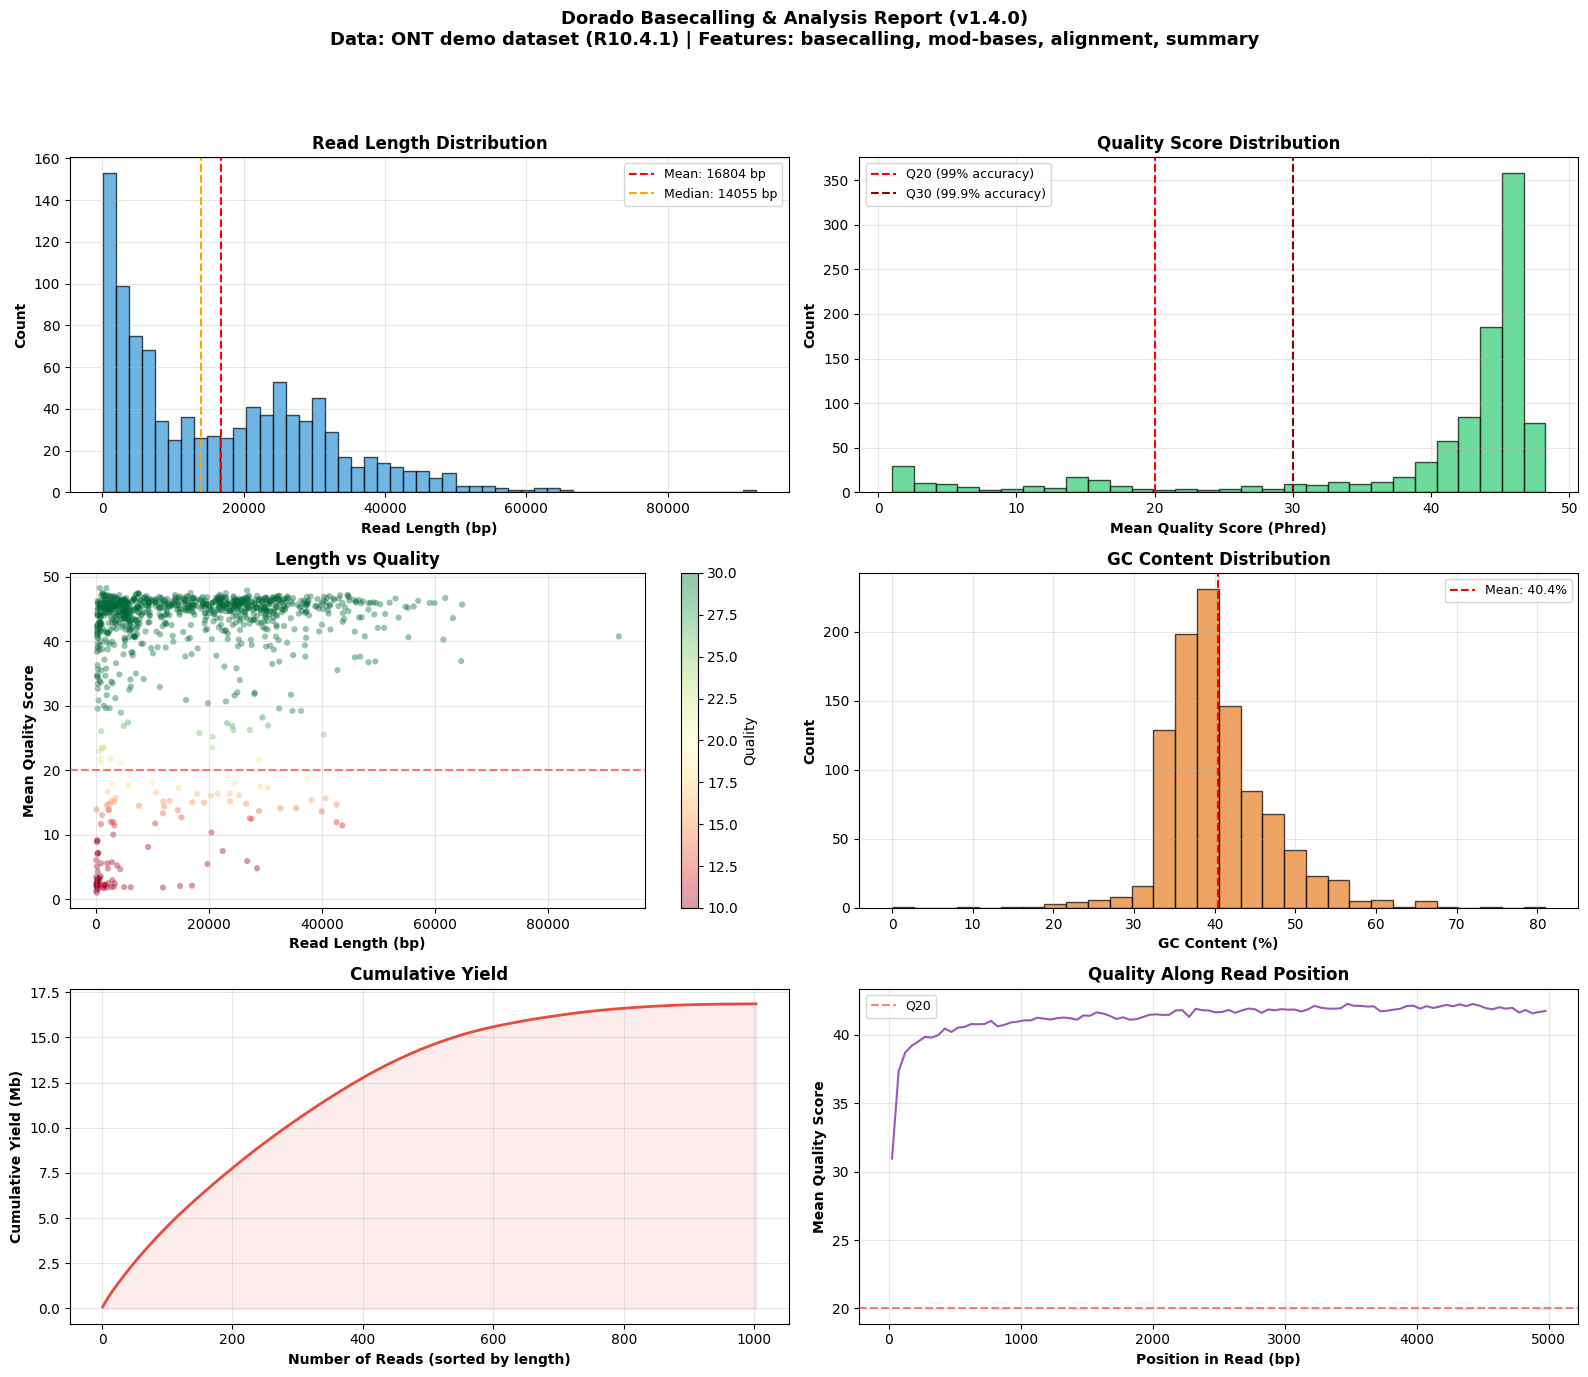


✓ Quality report saved


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

read_lengths = []
mean_qualities = []
gc_contents = []

for record in SeqIO.parse("dorado_results/basecalled.fastq", "fastq"):
    seq = str(record.seq)
    read_lengths.append(len(seq))
    quals = record.letter_annotations["phred_quality"]
    mean_qualities.append(np.mean(quals))
    if len(seq) > 0:
        gc = (seq.count('G') + seq.count('C')) / len(seq) * 100
        gc_contents.append(gc)

read_lengths = np.array(read_lengths)
mean_qualities = np.array(mean_qualities)
gc_contents = np.array(gc_contents)
total_bases = sum(read_lengths)

print("=" * 60)
print("BASECALLING QUALITY SUMMARY")
print("=" * 60)
print(f"  Total reads:       {len(read_lengths)}")
print(f"  Total bases:       {total_bases:,}")
print(f"  Mean read length:  {np.mean(read_lengths):.0f} bp")
print(f"  Median length:     {np.median(read_lengths):.0f} bp")
print(f"  Longest read:      {np.max(read_lengths):,} bp")
print(f"  Mean quality:      Q{np.mean(mean_qualities):.1f}")
print(f"  Mean GC content:   {np.mean(gc_contents):.1f}%")
print(f"  Reads >= Q20:      {np.sum(mean_qualities >= 20)} ({np.sum(mean_qualities >= 20)/len(mean_qualities)*100:.1f}%)")

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Dorado Basecalling & Analysis Report (v1.4.0)\n"
             "Data: ONT demo dataset (R10.4.1) | Features: basecalling, mod-bases, alignment, summary",
             fontweight='bold', fontsize=13)

# Plot 1: Read length distribution
ax1 = fig.add_subplot(3, 2, 1)
ax1.hist(read_lengths, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(x=np.mean(read_lengths), color='red', linestyle='--',
            label=f'Mean: {np.mean(read_lengths):.0f} bp')
ax1.axvline(x=np.median(read_lengths), color='orange', linestyle='--',
            label=f'Median: {np.median(read_lengths):.0f} bp')
ax1.set_xlabel("Read Length (bp)", fontweight='bold')
ax1.set_ylabel("Count", fontweight='bold')
ax1.set_title("Read Length Distribution", fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Quality score distribution
ax2 = fig.add_subplot(3, 2, 2)
ax2.hist(mean_qualities, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
ax2.axvline(x=20, color='red', linestyle='--', label='Q20 (99% accuracy)')
ax2.axvline(x=30, color='darkred', linestyle='--', label='Q30 (99.9% accuracy)')
ax2.set_xlabel("Mean Quality Score (Phred)", fontweight='bold')
ax2.set_ylabel("Count", fontweight='bold')
ax2.set_title("Quality Score Distribution", fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Length vs Quality (color-coded)
ax3 = fig.add_subplot(3, 2, 3)
scatter = ax3.scatter(read_lengths, mean_qualities, alpha=0.4, s=20,
            c=mean_qualities, cmap='RdYlGn', edgecolors='none',
            vmin=10, vmax=30)
ax3.set_xlabel("Read Length (bp)", fontweight='bold')
ax3.set_ylabel("Mean Quality Score", fontweight='bold')
ax3.set_title("Length vs Quality", fontweight='bold')
ax3.axhline(y=20, color='red', linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Quality')

# Plot 4: GC Content Distribution
ax4 = fig.add_subplot(3, 2, 4)
ax4.hist(gc_contents, bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
ax4.axvline(x=np.mean(gc_contents), color='red', linestyle='--',
            label=f'Mean: {np.mean(gc_contents):.1f}%')
ax4.set_xlabel("GC Content (%)", fontweight='bold')
ax4.set_ylabel("Count", fontweight='bold')
ax4.set_title("GC Content Distribution", fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Plot 5: Cumulative yield
ax5 = fig.add_subplot(3, 2, 5)
sorted_lengths = np.sort(read_lengths)[::-1]
cumulative = np.cumsum(sorted_lengths)
ax5.plot(range(1, len(cumulative)+1), cumulative / 1e6,
         color='#e74c3c', linewidth=2)
ax5.fill_between(range(1, len(cumulative)+1), cumulative / 1e6,
                 alpha=0.1, color='#e74c3c')
ax5.set_xlabel("Number of Reads (sorted by length)", fontweight='bold')
ax5.set_ylabel("Cumulative Yield (Mb)", fontweight='bold')
ax5.set_title("Cumulative Yield", fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Per-position quality along reads
ax6 = fig.add_subplot(3, 2, 6)
max_len = min(5000, int(np.percentile(read_lengths, 90)))
position_quals = [[] for _ in range(max_len)]
for record in SeqIO.parse("dorado_results/basecalled.fastq", "fastq"):
    quals = record.letter_annotations["phred_quality"]
    for pos, q in enumerate(quals[:max_len]):
        position_quals[pos].append(q)

bin_size = max(1, max_len // 100)
binned_means = []
binned_positions = []
for i in range(0, max_len, bin_size):
    chunk = []
    for j in range(i, min(i + bin_size, max_len)):
        if position_quals[j]:
            chunk.extend(position_quals[j])
    if chunk:
        binned_means.append(np.mean(chunk))
        binned_positions.append(i + bin_size // 2)

ax6.plot(binned_positions, binned_means, color='#9b59b6', linewidth=1.5)
ax6.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Q20')
ax6.set_xlabel("Position in Read (bp)", fontweight='bold')
ax6.set_ylabel("Mean Quality Score", fontweight='bold')
ax6.set_title("Quality Along Read Position", fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("dorado_results/dorado_quality_report.png", dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Quality report saved")

In [25]:
import numpy as np

with open("dorado_results/dorado_analysis_summary.txt", "w") as f:
    f.write("Dorado Basecalling Analysis Summary\n")
    f.write("=" * 50 + "\n\n")
    f.write("Dorado version: 1.4.0\n")
    f.write("Data source: ONT official demo dataset (R10.4.1)\n\n")
    f.write("Features Demonstrated:\n")
    f.write(f"  1. Standard basecalling (sup model): {elapsed_bc:.1f}s\n")
    f.write(f"  2. Modified base detection (5mCG_5hmCG): {elapsed_mod:.1f}s\n")
    f.write(f"  3. Basecall + alignment (built-in minimap2): {elapsed_align:.1f}s\n")
    f.write(f"  4. Per-read QC summary (dorado summary)\n\n")
    f.write("Basecalling Results:\n")
    f.write(f"  Total reads: {len(read_lengths)}\n")
    f.write(f"  Total bases: {total_bases:,}\n")
    f.write(f"  Mean read length: {np.mean(read_lengths):.0f} bp\n")
    f.write(f"  Median read length: {np.median(read_lengths):.0f} bp\n")
    f.write(f"  Longest read: {np.max(read_lengths):,} bp\n")
    f.write(f"  Mean quality: Q{np.mean(mean_qualities):.1f}\n")
    f.write(f"  Mean GC: {np.mean(gc_contents):.1f}%\n")
    f.write(f"  Reads >= Q20: {np.sum(mean_qualities >= 20)}/{len(mean_qualities)}\n\n")
    f.write("Output Files:\n")
    f.write("  basecalled.fastq         — standard basecalls (FASTQ)\n")
    f.write("  modbase.bam              — basecalls + methylation tags (MM/ML)\n")
    f.write("  aligned_sorted.bam       — basecalls aligned to reference\n")
    f.write("  aligned_sorted.bam.bai   — BAM index\n")
    f.write("  read_summary.tsv         — per-read QC metrics\n")
    f.write("  dorado_quality_report.png — 6-panel quality analysis\n")

print("✓ Summary saved\n")

!zip -r -q dorado_results.zip dorado_results/

print("Files in package:")
!ls -lh dorado_results/

from google.colab import files
files.download('dorado_results.zip')
print("\n✓ Download complete")
print("\nCopy to: Stowers_gpu_tools/dorado/results/sample_output/")

✓ Summary saved

Files in package:
total 70M
-rw-r--r-- 1 root root  12M Mar  8 19:56 aligned.bam
-rw-r--r-- 1 root root 1.1K Mar  8 19:56 aligned.log
-rw-r--r-- 1 root root  12M Mar  8 19:56 aligned_sorted.bam
-rw-r--r-- 1 root root   24 Mar  8 19:56 aligned_sorted.bam.bai
-rw-r--r-- 1 root root  33M Mar  8 19:35 basecalled.fastq
-rw-r--r-- 1 root root 1.1K Mar  8 19:35 basecall.log
-rw-r--r-- 1 root root  945 Mar  8 19:58 dorado_analysis_summary.txt
-rw-r--r-- 1 root root 835K Mar  8 19:57 dorado_quality_report.png
-rw-r--r-- 1 root root  13M Mar  8 19:43 modbase.bam
-rw-r--r-- 1 root root 1.1K Mar  8 19:43 modbase.log
-rw-r--r-- 1 root root 300K Mar  8 19:57 read_summary.tsv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download complete

Copy to: Stowers_gpu_tools/dorado/results/sample_output/
